In [1]:
!pip install qiskit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 55.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 73.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.4/54.4 kB 4.9 MB/s eta 0:00:00


In [2]:
!pip install pylatexenc

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 4.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=a8e9d5055f754856c4eb93bb2c722b175b95e4d90f65b22a67d161120bb096dd
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


In [3]:
!pip install qiskit-aer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 80.6 MB/s eta 0:00:00


In [4]:
import qiskit
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit.circuit.library import QFT
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator

import numpy as np
from fractions import Fraction
from math import gcd, floor, log

print("Versão do Qiskit:", qiskit.__version__)


Versão do Qiskit: 2.2.3


Nesta atividade vamos construir passo a passo a parte quântica do algoritmo de Shor para fatorar o número 15, usando a = 2.
O foco não é apenas executar o código, mas entender conceitualmente cada etapa:

- Construir o registrador de fase (controle).

- Construir o registrador alvo.

- Implementar expoenciação modular controlada.

- Aplicar a QFT inversa.

- Medir e interpretar os resultados.

- Extrair o período r e os fatores de 15.
## Definição do Problema e Funções Auxiliares

Nesta etapa definimos os elementos do problema clássico:

O número que queremos fatorar.

O valor de a que será usado para detectar a periodicidade.

Funções matemáticas auxiliares para analisar as medições do circuito

In [5]:
# Número que queremos fatorar
N = 15
# Escolha de 'a' coprimo com N (gcd(a, N) = 1)
a = 2

print(f"N = {N}, a = {a}, gcd(a, N) = {gcd(a, N)}")


def fraction_from_bitstring(bitstring, num_control):
    """
    Converte a string de bits medida em uma fração decimal/2^num_control.
    Ex: '01000000' -> 64/256 = 1/4
    """
    decimal = int(bitstring, 2)
    phase = decimal / (2 ** num_control)
    return decimal, phase


def guess_r_from_phase(phase, max_denominator=2**8):
    """
    Dada uma fase aproximada (float), usa frações contínuas
    para encontrar um denominador candidato a ser o período r.
    """
    frac = Fraction(phase).limit_denominator(max_denominator)
    return frac.denominator, frac


def get_factors_from_r(a, N, r):
    """
    Dado um 'a', um N e um período r, tenta extrair fatores não triviais de N.
    """
    if r % 2 != 0:
        return None

    x = pow(a, r // 2, N)  # a^(r/2) mod N
    cand1 = gcd(x - 1, N)
    cand2 = gcd(x + 1, N)

    fatores = set()
    for c in [cand1, cand2]:
        if c not in [1, N]:
            fatores.add(c)
            fatores.add(N // c)

    return sorted(fatores) if fatores else None


N = 15, a = 2, gcd(a, N) = 1


## Operadores de multiplicação modular M₂ e M₄ (mod 15)

Nesta etapa vamos construir, de forma explícita, as operações de **multiplicação modular** que o algoritmo de Shor precisa.

Trabalhando com **N = 15** e **a = 2**, a parte quântica do algoritmo precisa aplicar, para cada qubit de controle k, operações do tipo:

$|x\rangle \mapsto |a^{2^k} \cdot x \bmod 15\rangle$


Se calcularmos as potências:
- $2^{1} \bmod 15 = 2$

- $2^{2} \bmod 15 = 4$
- $2^{4} \bmod 15 = 16 \equiv 1 \pmod{15}$
- $2^{8} \bmod 15 = 256 \equiv 1 \pmod{15}$

obtemos a lista:


$a^{2^k} \bmod 15 = [2, 4, 1, 1].$

Isso significa que:

- para alguns qubits de controle, o circuito precisa **multiplicar por 2 (mod 15)**;
- para outros, precisa **multiplicar por 4 (mod 15)**;
- nos casos em que o resultado é 1, a operação é a identidade (não faz nada).

Por isso definimos exatamente **dois operadores unitários**:

- **M₂**: realiza $(|x\rangle \to |2x \bmod 15\rangle)$;
- **M₄**: realiza $(|x\rangle \to |4x \bmod 15\rangle)$.

Como estamos num exemplo pequeno, com 4 qubits para representar 0 a 15, essas multiplicações modulares viram **permutações simples entre os estados de base**. Em outras palavras, M₂ e M₄ apenas “embaralham” os estados $(|0000\rangle, |0001\rangle, \dots, |1111\rangle)$ de forma bem estruturada.

Isso é ótimo para fins didáticos, porque torna possível implementar esses operadores apenas com **portas SWAP** entre os qubits, sem precisar de construções mais complicadas. Nas células de código a seguir, aparecem as implementações de M₂ e M₄, seguidas de suas versões controladas, que serão usadas na etapa de exponenciação modular.


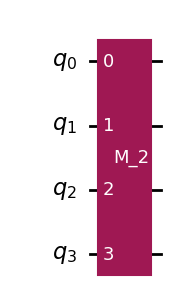

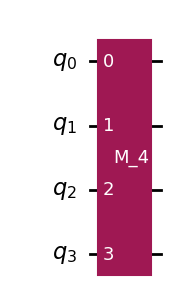

In [6]:
def M2mod15():
    """
    Operador M2: |x> -> |2x mod 15>, implementado com SWAPs em 4 qubits.
    """
    b = 2
    U = QuantumCircuit(4)

    # Essas SWAPs implementam a permutação para multiplicar por 2 (mod 15)
    U.swap(2, 3)
    U.swap(1, 2)
    U.swap(0, 1)

    U = U.to_gate()
    U.name = f"M_{b}"
    return U


def M4mod15():
    """
    Operador M4: |x> -> |4x mod 15>, também com SWAPs.
    """
    b = 4
    U = QuantumCircuit(4)

    U.swap(1, 3)
    U.swap(0, 2)

    U = U.to_gate()
    U.name = f"M_{b}"
    return U


def controlled_M2mod15():
    """
    Versão controlada de M2 (um controle + 4 qubits alvo).
    """
    U = M2mod15()
    c_U = U.control()
    return c_U


def controlled_M4mod15():
    """
    Versão controlada de M4 (um controle + 4 qubits alvo).
    """
    U = M4mod15()
    c_U = U.control()
    return c_U


# Teste rápido: desenhar M2 e M4 sozinhos
qc_test = QuantumCircuit(4)
qc_test.compose(M2mod15(), inplace=True)
display(qc_test.draw(output="mpl"))

qc_test2 = QuantumCircuit(4)
qc_test2.compose(M4mod15(), inplace=True)
display(qc_test2.draw(output="mpl"))


Função de exponenciação modular (aplicar $M_{a^{2^k}}$)

Aqui aproximamos a parte “pesada” do algoritmo: exponenciação modular quântica.
Para cada qubit de controle k, aplicamos o operador adequado

$$
M_{a^{2^k}} \text{mod}N
$$	​
 controlado.

In [7]:
def a2kmodN(a, k, N):
    """
    Calcula a^{2^k} mod N usando quadratura repetida.
    """
    for _ in range(k):
        a = (a * a) % N
    return a


def apply_controlled_modexp(circuit, control_qubits, target_qubits, a, N):
    """
    Para cada qubit de controle k, calcula b = a^{2^k} mod N
    e aplica o M_b controlado no registrador alvo.
    """

    num_control = len(control_qubits)

    # Lista de b = a^{2^k} (mod N)
    b_list = [a2kmodN(a, k, N) for k in range(num_control)]
    print("b_list (a^{2^k} mod N) =", b_list)

    for k, cq in enumerate(control_qubits):
        b = b_list[k]
        # Hadamard no qubit de controle (parte da PE)
        circuit.h(cq)

        # Escolhe qual operador modular aplicar
        if b == 2:
            circuit.compose(
                controlled_M2mod15(),
                qubits=[cq] + list(target_qubits),
                inplace=True,
            )
        elif b == 4:
            circuit.compose(
                controlled_M4mod15(),
                qubits=[cq] + list(target_qubits),
                inplace=True,
            )
        else:
            # b == 1 corresponde à identidade (não faz nada)
            pass


## Construindo o circuito de busca de período (order finding)

Nesta etapa reunimos todos os blocos do algoritmo para montar a parte quântica responsável por estimar o período $r$ da função $f(x)=a^x \bmod N$.  
Nosso objetivo é preparar dois registradores:

### Registrador de controle (ou registrador de fase)
Este registrador armazena a superposição de todos os expoentes possíveis.  
Usamos **$n_c = 2n$ qubits**, onde $n = \lceil \log_2(N) \rceil$ é o número de qubits necessários para representar o espaço modular.

Para $N = 15$, temos $n = 4$.  
Logo, o registrador de controle terá:
$$ n_c = 2n = 8 	\text{ qubits}$$

Por que dobrar o número de qubits?

Porque a QFT inversa irá resolver uma fração do tipo:
$$ \frac{s}{2^{n_c}} \approx \frac{r}{	\text{algum denominador}} $$
Quanto maior $2^{n_c}$, maior a **resolução** da estimativa da fase, aumentando a chance de recuperar corretamente o período $r$.

Essa escolha de $2n$ é usada em praticamente todas as implementações didáticas de Shor.

---

### Registrador alvo
Este registrador armazena o valor modular sobre o qual vamos aplicar $a^x \bmod N$.

Ele deve representar números entre 0 e $N-1$, portanto usamos:
$$ n = \lceil \log_2(N) \rceil $$
Para $N=15$, usamos 4 qubits.

Inicializamos o alvo no estado:
$$ |1\rangle = |0001\rangle$$

porque $a^0 \bmod N = 1$ e o algoritmo constrói as potências sucessivamente.

---

### Operações controladas de exponenciação modular

Cada qubit de controle aplica (ou não) uma operação do tipo:
$$ |x\rangle \longmapsto |a^{2^k} \cdot x \bmod N\rangle $$

Essas operações já foram preparadas antes como $M_2$ e $M_4$.  
Agora, unimos tudo: cada qubit de controle recebe um $H$, cria a superposição, e então controla um dos operadores.

---

### Aplicação da QFT inversa

Após a interferência quântica entre as potências de $a$, o registrador de controle contém informações sobre a fase:
$$ \phi = \frac{s}{r} $$
Aplicar a QFT inversa transforma essa fase em padrões de bits que podem ser medidos.

---

### Medida dos qubits de controle

Ao medir, obtemos valores que aproximam múltiplos de $\frac{2^{n_c}}{r}$.  
Esses valores serão traduzidos em frações para recuperar o período $r$.

b_list (a^{2^k} mod N) = [2, 4, 1, 1, 1, 1, 1, 1]


/tmp/ipython-input-2534803101.py:19: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qft_dagger = QFT(num_control, inverse=True)


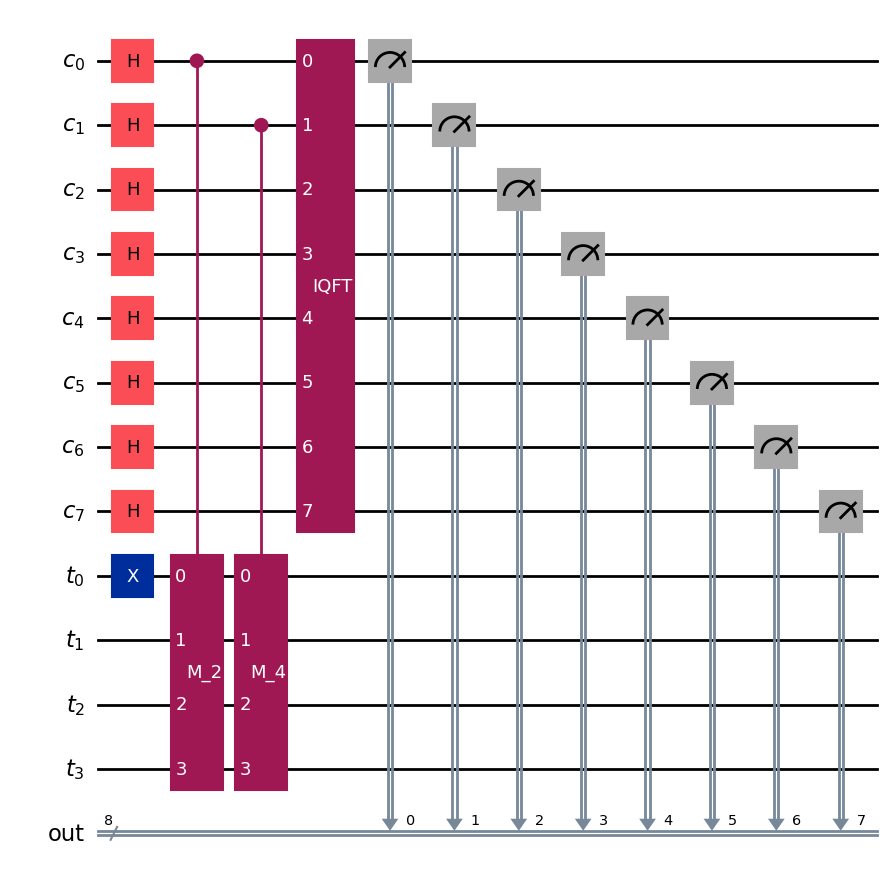

In [8]:
def build_order_finding_circuit(N=15, a=2):
    num_target = floor(log(N - 1, 2)) + 1  # nº de qubits para representar 0..N-1
    num_control = 2 * num_target          # para boa precisão na estimativa da fase

    # Registradores
    control = QuantumRegister(num_control, name="c")
    target = QuantumRegister(num_target, name="t")
    c_out = ClassicalRegister(num_control, name="out")

    qc = QuantumCircuit(control, target, c_out)

    # Inicializa alvo em |1>
    qc.x(target[0])

    # Exponenciação modular controlada
    apply_controlled_modexp(qc, control, target, a, N)

    # Aplica QFT inversa no registrador de controle
    qft_dagger = QFT(num_control, inverse=True)
    qc.compose(qft_dagger, qubits=control, inplace=True)

    # Medida dos qubits de controle
    qc.measure(control, c_out)

    return qc


order_circuit = build_order_finding_circuit(N, a)
display(order_circuit.draw(output="mpl", fold=-1))


## Simulação com AerSimulator

Agora que o circuito completo foi construído, precisamos executá‑lo em um backend quântico (no nosso caso, um simulador clássico ideal, sem ruído).

A simulação nos permitirá coletar muitas amostras das medidas do registrador de controle, que devem concentrar‑se em valores próximos a:

$$ \frac{s}{2^{n_c}} $$

onde $s$ é um múltiplo inteiro de $\frac{2^{n_c}}{r}$.

---

### Por que rodar muitas amostras (shots)?
Mesmo em um simulador ideal, o estado final é uma distribuição de probabilidades.  
Os resultados mais prováveis representam as fases mais compatíveis com o período $r$.

Quanto maior o número de *shots*, mais nítida fica a distribuição estatística no histograma.

---

### Resultados Esperados

Para $a = 2$ e $N = 15$, sabemos que o período é:

$$ r = 4 $$

Então esperamos observar picos em valores correspondentes a:

$$ s = 0,\; 64,\; 128,\; 192 $$

pois:

$$ \frac{s}{2^{8}} = 0, \; 0.25, \; 0.5, \; 0.75 $$

O histograma deve refletir justamente essas posições, confirmando a periodicidade.

Resultados brutos das medições:
{'11000000': 499, '01000000': 473, '00000000': 507, '10000000': 569}


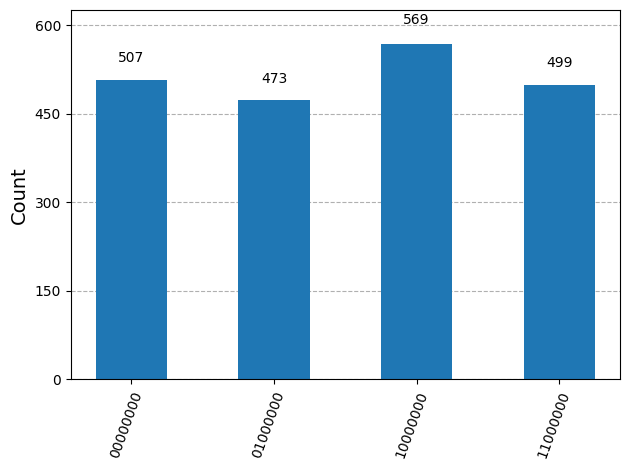

In [9]:
# Cria o simulador
simulator = AerSimulator()

# Transpila o circuito para o simulador (otimização simples)
compiled_circuit = transpile(order_circuit, simulator)

# Executa
job = simulator.run(compiled_circuit, shots=2048)
result = job.result()

counts = result.get_counts()
print("Resultados brutos das medições:")
print(counts)

plot_histogram(counts)


## Pós-processamento: extraindo o período $r$ e os fatores de $N$

Depois da medida, cada resultado corresponde a um valor inteiro:

$$ m \in \{0,1,2,\dots,2^{n_c}-1\} $$

Esse valor representa uma aproximação para:

$$ \frac{s}{2^{n_c}} \approx \frac{r'}{r} $$

onde:

- $r$ é o período real,
- $r'$ é um numerador que a interferência quântica selecionou.

---

### Convertendo o resultado para fase
Para cada bitstring medido:

$$ \text{fase} = \frac{m}{2^{n_c}} $$

---

###Aproximação por frações contínuas
Usamos a biblioteca `Fraction` para encontrar uma fração simples que aproxime a fase medida.

Se encontrarmos:

$$ \frac{r'}{r} $$

com denominador $r$ pequeno (e par, no caso específico de Shor), esse denominador será um candidato ao período.

---

### Testando os candidatos a período
Para cada $r$ candidato, verificamos se ele realmente funciona, testando:

$$ a^{r} \equiv 1 \pmod{N} $$

E então tentamos extrair os fatores por:

$$
\gcd(a^{r/2} - 1, N),\quad
\gcd(a^{r/2} + 1, N)
$$

Para $N=15$ e $a=2$, isso nos dá:

- $\gcd(2^{2}-1,15)=3$
- $\gcd(2^{2}+1,15)=5$

que são os fatores esperados.

---

### Conclusão do processo
A medida fornece probabilidades concentradas em múltiplos de $\frac{1}{r}$.  
A QFT torna isso visível em termos de bits.  
O processamento clássico reconstrói o período.  
E o período fornece os fatores não triviais de $N$.

Isso encerra o ciclo completo do algoritmo de Shor.

In [10]:
num_control = order_circuit.num_qubits - (floor(log(N - 1, 2)) + 1)  # 8 no nosso caso

print(f"Número de qubits de controle (num_control) = {num_control}\n")

candidatos_r = set()
fatores_encontrados = set()

for bitstring, freq in counts.items():
    decimal, phase = fraction_from_bitstring(bitstring, num_control)
    r_cand, frac = guess_r_from_phase(phase, max_denominator=2**num_control)

    print(f"Saída {bitstring} (freq {freq}):")
    print(f"  decimal = {decimal}, phase ≈ {phase:.4f} ≈ {frac}")
    print(f"  r candidato (denominador) = {r_cand}")

    # Tenta extrair fatores a partir desse r
    fatores = get_factors_from_r(a, N, r_cand)
    if fatores:
        print(f"  -> Fatores possíveis de {N}: {fatores}\n")
        candidatos_r.add(r_cand)
        fatores_encontrados.update(fatores)
    else:
        print("  -> Este r não gerou fatores não triviais.\n")

print("Resumo:")
print("Candidatos de r:", candidatos_r if candidatos_r else "nenhum r útil")
print("Fatores encontrados:", fatores_encontrados if fatores_encontrados else "nenhum fator não trivial encontrado")


Número de qubits de controle (num_control) = 8

Saída 11000000 (freq 499):
  decimal = 192, phase ≈ 0.7500 ≈ 3/4
  r candidato (denominador) = 4
  -> Fatores possíveis de 15: [3, 5]

Saída 01000000 (freq 473):
  decimal = 64, phase ≈ 0.2500 ≈ 1/4
  r candidato (denominador) = 4
  -> Fatores possíveis de 15: [3, 5]

Saída 00000000 (freq 507):
  decimal = 0, phase ≈ 0.0000 ≈ 0
  r candidato (denominador) = 1
  -> Este r não gerou fatores não triviais.

Saída 10000000 (freq 569):
  decimal = 128, phase ≈ 0.5000 ≈ 1/2
  r candidato (denominador) = 2
  -> Fatores possíveis de 15: [3, 5]

Resumo:
Candidatos de r: {2, 4}
Fatores encontrados: {3, 5}


O algoritmo detectou corretamente que:

O período da função modular $2^x \bmod 15$ é 4.

Com $r = 4$, obtivemos os fatores 3 e 5.

Assim, o número composto:
15=3×5

é fatorado com sucesso.

Este processo é justamente a parte crítica que torna Shor tão poderoso: ele reduz a fatoração de números grandes ao problema de encontrar períodos, algo que um circuito quântico consegue estimar exponencialmente mais rápido que métodos clássicos conhecidos.

> # Conclusão: Interpretando os Resultados e Como a Fatoração Foi Obtida
>
> Após executar o circuito com 8 qubits de controle, o simulador retornou quatro valores principais:
>
> - 11000000 → fase 0.75  
> - 01000000 → fase 0.25  
> - 10000000 → fase 0.50  
> - 00000000 → fase 0
>
> Essas fases correspondem a 0, 1/4, 1/2 e 3/4, ou seja, múltiplos de 1/r.  
> Os valores se alinham exatamente aos múltiplos de 1/4, indicando que o período da função modular é:
>
> **r = 4**
>
> ---
> ---
> ## Período
>
> A função usada no algoritmo é:
>
> **f(x) = 2^x mod 15**
>
> Verificando os valores:

 - $2^0 = 1$  
 - $2^1 = 2$  
 - $2^2 = 4$  
 - $2^3 = 8$  
 - $2^4 = 16 ≡ 1 (mod 15)$

> A menor potência que volta ao valor 1 mod 15 é 4, então o período real é mesmo r = 4.  
> O circuito quântico detectou isso corretamente pelas fases medidas.

> Como o período r é par:
>
> - Calculamos: $2^\frac{r}{2} = 2^2 = 4$  
> - Testamos os candidatos:
>   - gcd(4 − 1, 15) = gcd(3, 15) = 3  
>   - gcd(4 + 1, 15) = gcd(5, 15) = 5  
>
> Portanto:
>
> **15 = 3 × 5**
>
> Os fatores corretos foram recuperados a partir do período identificado pelo circuito.
>
>
>

>
> O circuito quântico estimou corretamente que o período da função modular é 4.  
> Com essa informação, o pós-processamento clássico obteve os fatores 3 e 5, mostrando como o algoritmo de Shor “quebra” a chave baseada em fatoração.
>
Com isso temos a vantagem do algoritmo de Shor em contrapartida de métodos clássicos para solucionar o mesmo problema.